                                            Stacking (FNN + XGBoost) with higher order color indices

In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
import os
import random
import numpy as np
import tensorflow as tf

# Python random
random.seed(42)

# NumPy
np.random.seed(42)

# TensorFlow
tf.random.set_seed(42)


os.environ['PYTHONHASHSEED'] = '42'

In [36]:

df = pd.read_csv(r"C:\Users\PIYUSH\Downloads\StarGalaxyQuaser1_TwinkleKashyap.csv")

if 'objid' in df.columns:
    df.drop('objid', axis=1, inplace=True)

In [37]:
#  FEATURE ENGINEERING 

# Basic colors
df['u_g'] = df['u'] - df['g']
df['g_r'] = df['g'] - df['r']
df['r_i'] = df['r'] - df['i']
df['i_z'] = df['i'] - df['z']

#  Higher-order colors
df['u_r'] = df['u'] - df['r']
df['g_i'] = df['g'] - df['i']
df['r_z'] = df['r'] - df['z']

# cleaning
df = df[(df['u_g'] > -5) & (df['u_g'] < 5) &
        (df['g_r'] > -5) & (df['g_r'] < 5)]

In [39]:
# LABEL ENCODING 
le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

#  FEATURES 
X = df.drop('class', axis=1)
y = df['class']

In [40]:
import joblib
joblib.dump(X.columns, "features.pkl")

['features.pkl']

In [41]:
# TRAIN TEST SPLIT 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [42]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [43]:
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [44]:
#  K-FOLD  
kf = KFold(n_splits=5, shuffle=True, random_state=42)
n_classes = 3

oof_xgb = np.zeros((X_train.shape[0], n_classes))
oof_fnn = np.zeros((X_train.shape[0], n_classes))

test_xgb = np.zeros((X_test.shape[0], n_classes))
test_fnn = np.zeros((X_test.shape[0], n_classes))

In [45]:
#  K-FOLD TRAINING 
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"\nFold {fold+1}")

    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    X_tr_scaled = X_train_scaled[train_idx]
    X_val_scaled = X_train_scaled[val_idx]
    #  XGBOOST 
    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        random_state=42
    )

    xgb.fit(X_tr, y_tr)
    joblib.dump(xgb, "xgb_model.pkl")
    oof_xgb[val_idx] = xgb.predict_proba(X_val)
    test_xgb += xgb.predict_proba(X_test) / 5

    #  FNN 
    model = keras.Sequential([
        keras.Input(shape=(X_tr_scaled.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Class weights
    classes = np.unique(y_tr)
    weights = compute_class_weight('balanced', classes=classes, y=y_tr)
    class_weights = dict(zip(classes, weights))

    model.fit(
        X_tr_scaled, y_tr,
        epochs=40,
        batch_size=64,
        verbose=0,
        class_weight=class_weights
    )
    model.save("fnn_model.keras")
    oof_fnn[val_idx] = model.predict(X_val_scaled)
    test_fnn += model.predict(X_test_scaled) / 5


Fold 1
433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 832us/step
928/928 ━━━━━━━━━━━━━━━━━━━━ 1s 766us/step

Fold 2
433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 837us/step
928/928 ━━━━━━━━━━━━━━━━━━━━ 1s 825us/step

Fold 3
433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 852us/step
928/928 ━━━━━━━━━━━━━━━━━━━━ 1s 774us/step

Fold 4
433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 856us/step
928/928 ━━━━━━━━━━━━━━━━━━━━ 1s 820us/step

Fold 5
433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 830us/step
928/928 ━━━━━━━━━━━━━━━━━━━━ 1s 759us/step


In [46]:
# META MODEL 
meta_X_train = np.hstack([oof_xgb, oof_fnn])
meta_X_test = np.hstack([test_xgb, test_fnn])

meta_model = LogisticRegression(max_iter=1000)
meta_model.fit(meta_X_train, y_train)



,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [47]:
joblib.dump(meta_model, "meta_model.pkl")

['meta_model.pkl']

In [48]:
#  FINAL PREDICTION 
final_pred = meta_model.predict(meta_X_test)

In [49]:
#  EVALUATION 
print("\nK-Fold Stacking Accuracy:", accuracy_score(y_test, final_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_pred))
print("\nClassification Report:")
print(classification_report(y_test, final_pred))


K-Fold Stacking Accuracy: 0.9939675799548411

Confusion Matrix:
[[17511    46    21]
 [  110  2656     0]
 [    2     0  9327]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99     17578
           1       0.98      0.96      0.97      2766
           2       1.00      1.00      1.00      9329

    accuracy                           0.99     29673
   macro avg       0.99      0.99      0.99     29673
weighted avg       0.99      0.99      0.99     29673



In [50]:
def plot_conf_matrix(y_true, final_pred , title):
    cm = confusion_matrix(y_true, final_pred )
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='RdPu',linewidths=0.5, linecolor='black')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

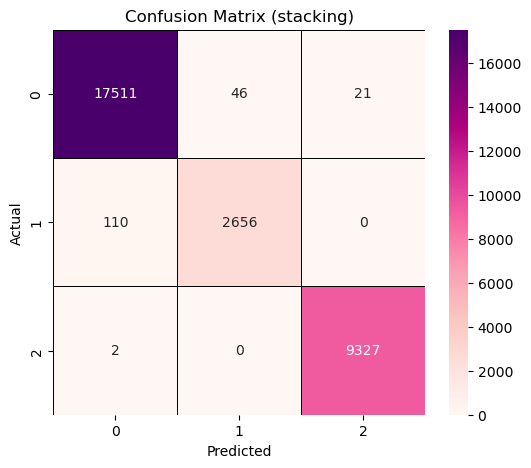

In [51]:
plot_conf_matrix(y_test,final_pred , "Confusion Matrix (stacking)")

In [52]:
from sklearn.metrics import accuracy_score

# XGB only
pred_xgb = np.argmax(test_xgb, axis=1)
print("XGB Accuracy:", accuracy_score(y_test, pred_xgb))

# FNN only
pred_fnn = np.argmax(test_fnn, axis=1)
print("FNN Accuracy:", accuracy_score(y_test, pred_fnn))

# Stacking
pred_stack = final_pred
print("Stacking Accuracy:", accuracy_score(y_test, final_pred))

XGB Accuracy: 0.9939675799548411
FNN Accuracy: 0.990361608196003
Stacking Accuracy: 0.9939675799548411


In [53]:
acc_xgb = accuracy_score(y_test, pred_xgb)
acc_fnn = accuracy_score(y_test, pred_fnn)
acc_stack = accuracy_score(y_test, pred_stack)

In [54]:
pred_xgb = np.argmax(test_xgb, axis=1)
pred_fnn = np.argmax(test_fnn, axis=1)

agree = (pred_xgb == pred_fnn)
disagree = (pred_xgb != pred_fnn)

print("Agreement %:", agree.mean())

# Accuracy when models agree
acc_agree = (final_pred[agree] == y_test[agree]).mean()

# Accuracy when models disagree
acc_disagree = (final_pred[disagree] == y_test[disagree]).mean()

print("Accuracy (agree):", acc_agree)
print("Accuracy (disagree):", acc_disagree)

Agreement %: 0.9939001786135544
Accuracy (agree): 0.9951851349518513
Accuracy (disagree): 0.7955801104972375


In [55]:
probs = meta_model.predict_proba(meta_X_test)
confidence = probs.max(axis=1)
high_conf = (confidence > 0.9).sum()
print("High confidence samples:", high_conf)

High confidence samples: 29530


                                                          without Redshift 

In [56]:
# Remove redshift 
if 'redshift' in X.columns:
    X = X.drop('redshift', axis=1)

In [57]:
joblib.dump(X.columns, "features_no_z.pkl")

['features_no_z.pkl']

In [58]:
#  TRAIN TEST SPLIT 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [59]:

scaler_no_z = StandardScaler()
X_train_scaled = scaler_no_z.fit_transform(X_train)
X_test_scaled = scaler_no_z.transform(X_test)


In [60]:
joblib.dump(scaler_no_z, "scaler_no_z.pkl")

['scaler_no_z.pkl']

In [61]:
#  K-FOLD SETUP 
kf = KFold(n_splits=5, shuffle=True, random_state=42)
n_classes = 3

oof_xgb = np.zeros((X_train.shape[0], n_classes))
oof_fnn = np.zeros((X_train.shape[0], n_classes))

test_xgb = np.zeros((X_test.shape[0], n_classes))
test_fnn = np.zeros((X_test.shape[0], n_classes))

In [62]:
#  K-FOLD TRAINING 
for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    print(f"\nFold {fold+1}")

    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    X_tr_scaled = X_train_scaled[train_idx]
    X_val_scaled = X_train_scaled[val_idx]
    # XGBOOST 
    xgb_no_z = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='multi:softprob',
        num_class=3,
        eval_metric='mlogloss',
        random_state=42
    )

    xgb_no_z.fit(X_tr, y_tr)
    joblib.dump(xgb_no_z, "xgb_model_no_z.pkl")

    oof_xgb[val_idx] = xgb_no_z.predict_proba(X_val)
    test_xgb += xgb_no_z.predict_proba(X_test) / 5

    #  FNN 
    model_no_z = keras.Sequential([
        keras.Input(shape=(X_tr_scaled.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])

    model_no_z.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # Class weights
    classes = np.unique(y_tr)
    weights = compute_class_weight('balanced', classes=classes, y=y_tr)
    class_weights = dict(zip(classes, weights))

    model_no_z.fit(
        X_tr_scaled, y_tr,
        epochs=40,
        batch_size=64,
        verbose=0,
        class_weight=class_weights
    )

    model_no_z.save("fnn_model_no_z.keras")

    oof_fnn[val_idx] = model_no_z.predict(X_val_scaled)
    test_fnn += model_no_z.predict(X_test_scaled) / 5


Fold 1
433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 834us/step
928/928 ━━━━━━━━━━━━━━━━━━━━ 1s 764us/step

Fold 2
433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 827us/step
928/928 ━━━━━━━━━━━━━━━━━━━━ 1s 795us/step

Fold 3
433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step
928/928 ━━━━━━━━━━━━━━━━━━━━ 1s 773us/step

Fold 4
433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 862us/step
928/928 ━━━━━━━━━━━━━━━━━━━━ 1s 786us/step

Fold 5
433/433 ━━━━━━━━━━━━━━━━━━━━ 0s 841us/step
928/928 ━━━━━━━━━━━━━━━━━━━━ 1s 763us/step


In [64]:
#  META MODEL 
meta_X_train = np.hstack([oof_xgb, oof_fnn])
meta_X_test = np.hstack([test_xgb, test_fnn])

meta_model_no_z = LogisticRegression(max_iter=1000)
meta_model_no_z.fit(meta_X_train, y_train)

#  FINAL PREDICTION
final_pred = meta_model_no_z.predict(meta_X_test)

In [65]:
joblib.dump(meta_model_no_z, "meta_model_no_z.pkl")

['meta_model_no_z.pkl']

In [66]:
#  EVALUATION 
print("\nK-Fold Stacking Accuracy:", accuracy_score(y_test, final_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, final_pred))
print("\nClassification Report:")
print(classification_report(y_test, final_pred))


K-Fold Stacking Accuracy: 0.9347555016344825

Confusion Matrix:
[[17079   104   395]
 [  133  2313   320]
 [  687   297  8345]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96     17578
           1       0.85      0.84      0.84      2766
           2       0.92      0.89      0.91      9329

    accuracy                           0.93     29673
   macro avg       0.91      0.90      0.90     29673
weighted avg       0.93      0.93      0.93     29673



In [67]:
def plot_conf_matrix(y_true, final_pred , title):
    cm = confusion_matrix(y_true, final_pred )
    
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd',linewidths=0.5, linecolor='black')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

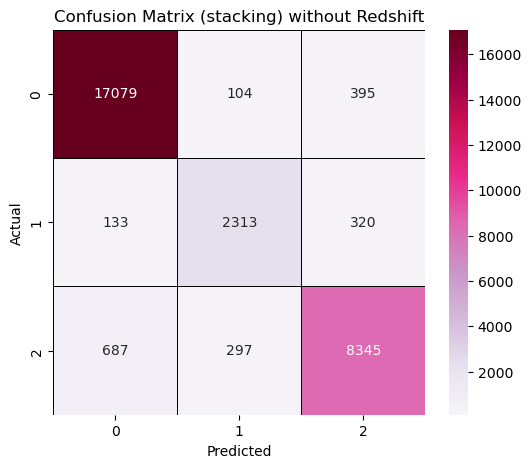

In [68]:
plot_conf_matrix(y_test,final_pred , "Confusion Matrix (stacking) without Redshift")

In [69]:
from sklearn.metrics import accuracy_score

# XGB only
pred_xgb = np.argmax(test_xgb, axis=1)
print("XGB Accuracy:", accuracy_score(y_test, pred_xgb))

# FNN only
pred_fnn = np.argmax(test_fnn, axis=1)
print("FNN Accuracy:", accuracy_score(y_test, pred_fnn))

# Stacking
pred_stack = final_pred
print("Stacking Accuracy:", accuracy_score(y_test, final_pred))

XGB Accuracy: 0.934317392916119
FNN Accuracy: 0.9258248239139959
Stacking Accuracy: 0.9347555016344825


In [70]:
acc_xgb = accuracy_score(y_test, pred_xgb)
acc_fnn = accuracy_score(y_test, pred_fnn)
acc_stack = accuracy_score(y_test, pred_stack)

In [71]:
pred_xgb = np.argmax(test_xgb, axis=1)
pred_fnn = np.argmax(test_fnn, axis=1)

agree = (pred_xgb == pred_fnn)
disagree = (pred_xgb != pred_fnn)

print("Agreement %:", agree.mean())

# Accuracy when models agree
acc_agree = (final_pred[agree] == y_test[agree]).mean()

# Accuracy when models disagree
acc_disagree = (final_pred[disagree] == y_test[disagree]).mean()

print("Accuracy (agree):", acc_agree)
print("Accuracy (disagree):", acc_disagree)

Agreement %: 0.9579415630371044
Accuracy (agree): 0.950395778364116
Accuracy (disagree): 0.5785256410256411


In [72]:
probs = meta_model.predict_proba(meta_X_test)
confidence = probs.max(axis=1)
high_conf = (confidence > 0.9).sum()
print("High confidence samples:", high_conf)

High confidence samples: 28000
